# **Mammalian Location Preditor**

## Objectives

The objective of this notebook is to explore, inspect, and prepare the National
Mammal Atlas Project dataset for downstream analysis and machine learning.
This includes assessing data quality, understanding temporal and spatial
coverage, applying structured cleaning steps, and engineering analytically
useful features. The outcome is a cleaned and well-documented dataset suitable
for exploratory analysis, visualisation, and predictive modelling.

## Inputs

* Data resource - National Mammal Atlas Project.csv

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 

## AI-Assisted Exploratory Data Analysis

An AI assistant (ChatGPT) was used during the exploratory data analysis phase to:
- suggest appropriate visualisations for categorical and spatial data,
- identify potential data quality issues,
- recommend transformations for high-cardinality categorical fields,
- support interpretation of observed patterns.

All analytical decisions were reviewed and validated manually before inclusion.



---

# Loading csv

In [189]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


# Get the directory where THIS notebook file lives
NOTEBOOK_DIR = Path.cwd()

# If VS Code started higher up, detect and adjust
if NOTEBOOK_DIR.name != "jupyter_notebooks":
    NOTEBOOK_DIR = NOTEBOOK_DIR / "jupyter_notebooks"

PROJECT_ROOT = NOTEBOOK_DIR.parent

DATA_PATH = PROJECT_ROOT / "inputs" / "Data resource - National Mammal Atlas Project.csv"

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("File exists:", DATA_PATH.exists())
print("Path:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head()

Notebook dir: c:\Users\tomoz\OneDrive\Documents\Software Engineering\capstone_project\uk_animal_tracker\jupyter_notebooks
Project root: c:\Users\tomoz\OneDrive\Documents\Software Engineering\capstone_project\uk_animal_tracker
File exists: True
Path: c:\Users\tomoz\OneDrive\Documents\Software Engineering\capstone_project\uk_animal_tracker\inputs\Data resource - National Mammal Atlas Project.csv


,Scientific name,Common name,Species ID (TVK),Taxon Rank,Start date,Start date day,Start date month,Start date year,Latitude (WGS84),Longitude (WGS84),...,Survey key,Kingdom,Phylum,Class,Order,Family,Genus,Country,State/Province,Vitality
0,Capreolus capreolus,Roe Deer,NHMSYS0000080203,species,31/01/2018,31,1,2018,57.400200,-4.267900,...,iRecord | Mammals,Animalia,Chordata,Mammalia,Artiodactyla,Cervidae,Capreolus,United Kingdom,Scotland,NaN
1,Erinaceus europaeus,West European Hedgehog,NBNSYS0000005078,species,20/01/2021,20,1,2021,51.519214,-0.738969,...,iRecord | App,Animalia,Chordata,Mammalia,Insectivora,Erinaceidae,Erinaceus,United Kingdom,England,NaN
2,Halichoerus grypus,Grey Seal,NBNSYS0000005137,species,06/01/2016,6,1,2016,52.800000,1.600000,...,iRecord | Mammals,Animalia,Chordata,Mammalia,Carnivora,Phocidae,Halichoerus,United Kingdom,England,NaN
3,Talpa europaea,European Mole,NBNSYS0000005079,species,25/01/2017,25,1,2017,53.322473,-1.731987,...,iRecord | Import,Animalia,Chordata,Mammalia,Insectivora,Talpidae,Talpa,United Kingdom,England,NaN
4,Sciurus carolinensis,Eastern Grey Squirrel,NHMSYS0000332764,species,06/01/2016,6,1,2016,52.581700,-1.717600,...,iRecord | Mammals,Animalia,Chordata,Mammalia,Rodentia,Sciuridae,Sciurus,United Kingdom,England,NaN


---

# Inspection

In [190]:
# basic inspection
df.head()
df.tail()

# structure
df.shape
df.info()

# missing values
df.isna().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227322 entries, 0 to 227321
Data columns (total 23 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Scientific name                     227322 non-null  object 
 1   Common name                         227123 non-null  object 
 2   Species ID (TVK)                    227322 non-null  object 
 3   Taxon Rank                          227322 non-null  object 
 4   Start date                          227322 non-null  object 
 5   Start date day                      227322 non-null  int64  
 6   Start date month                    227322 non-null  int64  
 7   Start date year                     227322 non-null  int64  
 8   Latitude (WGS84)                    227321 non-null  float64
 9   Longitude (WGS84)                   227321 non-null  float64
 10  Coordinate uncertainty (m)          227321 non-null  float64
 11  Identification verificatio

Vitality                      227322
Genus                           1994
Family                          1473
State/Province                   230
Country                          230
Common name                      199
Order                            136
Latitude (WGS84)                   1
Longitude (WGS84)                  1
Coordinate uncertainty (m)         1
dtype: int64

---

# Cleaning Data & Saving

In [191]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) CONFIG
# -----------------------------
MIN_YEAR = 2014
UK_LAT_RANGE = (49, 61)
UK_LON_RANGE = (-9, 3)

# Grid size for anonymised spatial areas (~10–11 km)
GRID_SIZE = 0.1

order_to_group = {
    "Carnivora": "Carnivores",
    "Artiodactyla": "Herbivores & Ungulates",
    "Perissodactyla": "Herbivores & Ungulates",
    "Rodentia": "Rodents",
    "Chiroptera": "Bats",
    "Eulipotyphla": "Insectivores & Small Mammals",
    "Lagomorpha": "Lagomorphs",
    "Cetacea": "Marine Mammals",
    "Pinnipedia": "Marine Mammals",
}

# -----------------------------
# Preserve raw data
# -----------------------------
df_raw = df.copy()

# -----------------------------
# Standardise columns
# -----------------------------
df_work = df_raw.rename(columns=lambda c: c.strip())

# -----------------------------
# Parse dates
# -----------------------------
df_work["Start date parsed"] = pd.to_datetime(
    df_work.get("Start date"),
    errors="coerce",
    dayfirst=True
)

# -----------------------------
# Drop unusable columns
# -----------------------------
if "Vitality" in df_work.columns:
    df_work = df_work.drop(columns=["Vitality"])

# -----------------------------
# Drop rows missing essential geo
# -----------------------------
before = len(df_work)
df_work = df_work.dropna(subset=["Latitude (WGS84)", "Longitude (WGS84)"])
after_geo = len(df_work)

# -----------------------------
# Basic UK coordinate sanity bounds
# -----------------------------
df_work = df_work[
    df_work["Latitude (WGS84)"].between(*UK_LAT_RANGE) &
    df_work["Longitude (WGS84)"].between(*UK_LON_RANGE)
]
after_bounds = len(df_work)

# -----------------------------
# Feature engineering (Mammal Group)
# -----------------------------
df_work["Mammal Group"] = (
    df_work["Order"]
    .map(order_to_group)
    .fillna("Other Mammals")
)

# -----------------------------
# Feature engineering (Area Code)  ✅ BEST-PRACTICE FIX
# -----------------------------
df_work["lat_bin"] = np.floor(
    df_work["Latitude (WGS84)"] / GRID_SIZE
).astype(int)

df_work["lon_bin"] = np.floor(
    df_work["Longitude (WGS84)"] / GRID_SIZE
).astype(int)

df_work["Area Code"] = (
    "A_" +
    df_work["lat_bin"].astype(str) +
    "_" +
    df_work["lon_bin"].astype(str)
)

# -----------------------------
# Temporal cleaning (years >= MIN_YEAR)
# -----------------------------
df_clean = df_work[df_work["Start date year"] >= MIN_YEAR].copy()
after_year = len(df_clean)

# -----------------------------
# Quality checks + summary
# -----------------------------
print("----- Cleaning Summary -----")
print(f"Raw rows:                 {len(df_raw):,}")
print(f"After drop missing geo:   {after_geo:,}  (removed {before - after_geo:,})")
print(f"After UK bounds filter:   {after_bounds:,}  (removed {after_geo - after_bounds:,})")
print(f"After year >= {MIN_YEAR}:      {after_year:,}  (removed {after_bounds - after_year:,})")
print()
print(
    "Year range in df_clean:",
    int(df_clean["Start date year"].min()),
    "to",
    int(df_clean["Start date year"].max())
)
print()
print("Mammal Group counts (top 10):")
print(df_clean["Mammal Group"].value_counts().head(10))
print()
print("Columns available in df_clean:")
print(list(df_clean.columns))

# -----------------------------
# Guards (fail fast if pipeline breaks)
# -----------------------------
assert "Mammal Group" in df_clean.columns, "❌ Mammal Group missing"
assert "Area Code" in df_clean.columns, "❌ Area Code missing"
assert df_clean["Start date year"].min() >= MIN_YEAR, "❌ Pre-2014 data remains"

# -----------------------------
# Export csv
# -----------------------------
out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

csv_path = out_dir / "mammal_atlas_cleaned.csv"
df_clean.to_csv(csv_path, index=False)

print("\nSaved:", csv_path.resolve())



----- Cleaning Summary -----
Raw rows:                 227,322
After drop missing geo:   227,321  (removed 1)
After UK bounds filter:   227,307  (removed 14)
After year >= 2014:      201,245  (removed 26,062)

Year range in df_clean: 2014 to 2023

Mammal Group counts (top 10):
Mammal Group
Carnivores                44878
Rodents                   42150
Other Mammals             37365
Lagomorphs                36336
Herbivores & Ungulates    23298
Bats                      17218
Name: count, dtype: int64

Columns available in df_clean:
['Scientific name', 'Common name', 'Species ID (TVK)', 'Taxon Rank', 'Start date', 'Start date day', 'Start date month', 'Start date year', 'Latitude (WGS84)', 'Longitude (WGS84)', 'Coordinate uncertainty (m)', 'Identification verification status', 'Basis of record', 'Survey key', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Country', 'State/Province', 'Start date parsed', 'Mammal Group', 'lat_bin', 'lon_bin', 'Area Code']

Saved: C:\Users\t

In [192]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({"missing": missing, "missing_%": missing_pct}).head(12)


,missing,missing_%
Vitality,227322,100.00
Genus,1994,0.88
Family,1473,0.65
State/Province,230,0.10
Country,230,0.10
Common name,199,0.09
Order,136,0.06
Latitude (WGS84),1,0.00
Longitude (WGS84),1,0.00
Coordinate uncertainty (m),1,0.00


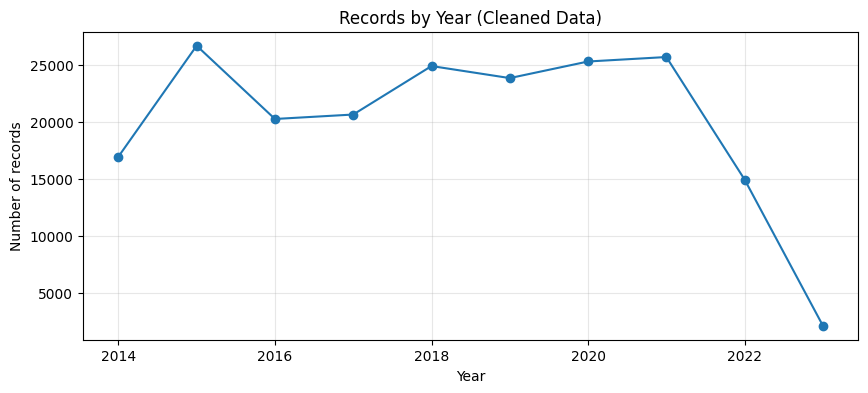

Start date year
2014    16937
2015    26681
2016    20249
2017    20639
2018    24896
2019    23839
2020    25296
2021    25688
2022    14925
2023     2095
Name: count, dtype: int64

In [193]:
year_counts = df_clean["Start date year"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Records by Year (Cleaned Data)")
plt.xlabel("Year")
plt.ylabel("Number of records")
plt.grid(alpha=0.3)
plt.show()

year_counts



In [194]:
# -----------------------------
# CONFIG
# -----------------------------
TOP_SPECIES = 5  # number of species to show per group

# -----------------------------
# Build species counts per group
# -----------------------------
species_counts = (
    df_clean
    .dropna(subset=["Mammal Group", "Common name"])
    .groupby(["Mammal Group", "Common name"])
    .size()
    .reset_index(name="count")
)

# Keep top N species per group
species_summary = (
    species_counts
    .sort_values(["Mammal Group", "count"], ascending=[True, False])
    .groupby("Mammal Group")
    .head(TOP_SPECIES)
)

# -----------------------------
# Build hover text per group
# -----------------------------
hover_text = (
    species_summary
    .groupby("Mammal Group")
    .apply(
        lambda g: "<br>".join(
            f"{name}: {cnt:,}"
            for name, cnt in zip(g["Common name"], g["count"])
        )
    )
    .reset_index(name="species_breakdown")
)

# -----------------------------
# Group totals
# -----------------------------
group_counts = (
    df_clean["Mammal Group"]
    .value_counts()
    .reset_index()
)

group_counts.columns = ["Mammal Group", "Record Count"]

# Attach hover breakdown
group_counts = group_counts.merge(
    hover_text,
    on="Mammal Group",
    how="left"
)

# -----------------------------
# Pie chart
# -----------------------------
fig = px.pie(
    group_counts,
    values="Record Count",
    names="Mammal Group",
    title="Distribution of Mammal Observation Records by Group",
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Total records: %{value:,}<br><br>"
        "<b>Top species:</b><br>"
        "%{customdata}<extra></extra>"
    ),
    customdata=group_counts["species_breakdown"]
)

fig.update_layout(showlegend=True)

fig.show()


This pie chart shows the proportion of mammal observation records belonging to
each mammal group in the cleaned dataset. The distribution reflects reporting
patterns and observer activity rather than true population size.


In [195]:
sample = df.sample(5000, random_state=42) if len(df) > 5000 else df

fig = px.scatter_mapbox(
    sample,
    lat="Latitude (WGS84)",
    lon="Longitude (WGS84)",
    hover_name="Common name",
    hover_data=["Scientific name", "Start date year", "State/Province"],
    zoom=4,
    height=600
)

fig.update_layout(mapbox_style="open-street-map", margin={"r":0,"t":0,"l":0,"b":0})
fig.show()


After restarting the kernel to install missing dependencies, all variables
were cleared and the data loading step was re-executed to restore the
analysis state.


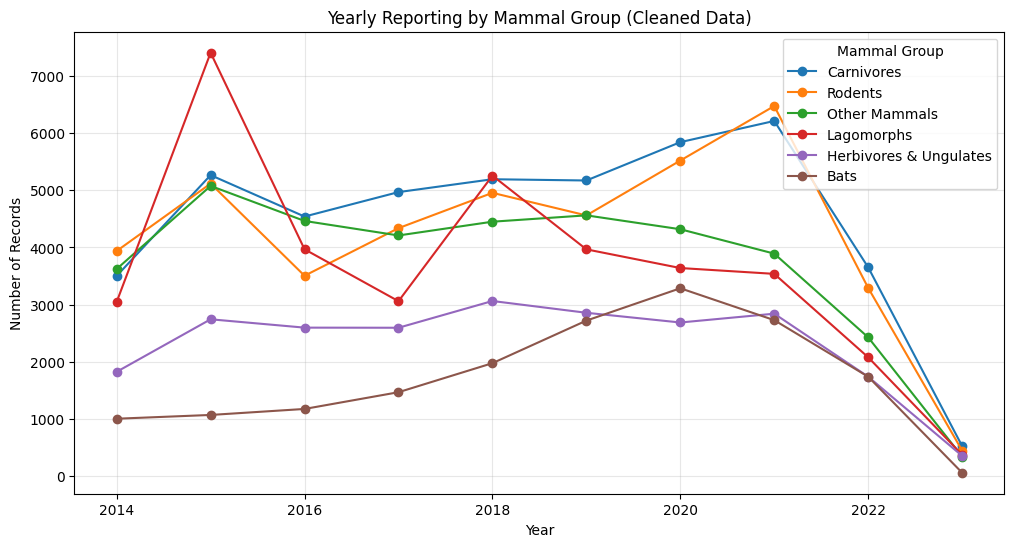

In [196]:
groups = [
    "Carnivores",
    "Rodents",
    "Other Mammals",
    "Lagomorphs",
    "Herbivores & Ungulates",
    "Bats",
]

yearly_group_counts = (
    df_clean[df_clean["Mammal Group"].isin(groups)]
    .groupby(["Start date year", "Mammal Group"])
    .size()
    .reset_index(name="records")
)

pivot = (
    yearly_group_counts
    .pivot(index="Start date year", columns="Mammal Group", values="records")
    .fillna(0)
    .sort_index()
)

plt.figure(figsize=(12, 6))

for g in groups:
    if g in pivot.columns:
        plt.plot(pivot.index, pivot[g], marker="o", label=g)

plt.title("Yearly Reporting by Mammal Group (Cleaned Data)")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.legend(title="Mammal Group")
plt.grid(alpha=0.3)
plt.show()




In [197]:
# Sample for performance (mapbox + large datasets)
sample = (
    df_clean.sample(5000, random_state=42)
    if len(df_clean) > 5000
    else df_clean
)

fig = px.scatter_mapbox(
    sample,
    lat="Latitude (WGS84)",
    lon="Longitude (WGS84)",
    color="Mammal Group",
    hover_name="Common name",
    hover_data=[
        "Scientific name",
        "Mammal Group",
        "Start date year",
        "State/Province",
    ],
    zoom=4,
    height=600,
    title="UK Mammal Observations by Mammal Group (Cleaned Data)",
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
)

fig.show()


In [198]:
# Count records per (Area Code, Mammal Group)
area_group_counts = (
    df_clean.groupby(["Area Code", "Mammal Group"])
    .size()
    .reset_index(name="group_count")
)

# Total records per Area Code
area_totals = (
    df_clean.groupby("Area Code")
    .size()
    .reset_index(name="area_total")
)

# Select dominant Mammal Group per Area Code
top_group_per_area = (
    area_group_counts
    .sort_values(["Area Code", "group_count"], ascending=[True, False])
    .groupby("Area Code", as_index=False)
    .first()
)

# Merge totals + compute dominance share
top_group_per_area = top_group_per_area.merge(area_totals, on="Area Code")
top_group_per_area["top_share"] = (
    top_group_per_area["group_count"] / top_group_per_area["area_total"]
).round(3)

# Compute centroids for each Area Code
area_centroids = (
    df_clean.groupby("Area Code")[["Latitude (WGS84)", "Longitude (WGS84)"]]
    .mean()
    .reset_index()
    .rename(columns={
        "Latitude (WGS84)": "area_lat",
        "Longitude (WGS84)": "area_lon",
    })
)

# Final dataframe for plotting
plot_df = top_group_per_area.merge(area_centroids, on="Area Code")

plot_df.head()


,Area Code,Mammal Group,group_count,area_total,top_share,area_lat,area_lon
0,A_491_-21,Rodents,8,9,0.889,49.190038,-2.050270
1,A_491_-22,Other Mammals,12,32,0.375,49.187205,-2.152610
2,A_491_-23,Lagomorphs,3,9,0.333,49.185392,-2.222199
3,A_492_-21,Rodents,21,39,0.538,49.219291,-2.066865
4,A_492_-22,Rodents,41,97,0.423,49.214858,-2.122733


---

In [199]:
TOP_AREAS = 300

plot_df_top = plot_df.sort_values("area_total", ascending=False).head(TOP_AREAS)

fig = px.scatter_mapbox(
    plot_df_top,
    lat="area_lat",
    lon="area_lon",
    size="area_total",
    color="Mammal Group",
    hover_name="Mammal Group",
    hover_data={
        "Area Code": True,
        "group_count": True,
        "area_total": True,
        "top_share": True,
    },
    zoom=4,
    center={"lat": 54.5, "lon": -3},
    height=650,
    title=f"Dominant Mammal Group per Area Code — Top {TOP_AREAS} Areas",
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()


For each anonymised spatial area, the dominant mammal group is identified as the
most frequently reported group. Spatial centroids are used for visualisation.
Results reflect reporting patterns rather than true population abundance. Circle size = total number of mammal observation records within that Area Code.

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.